In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [9]:
print("Loading")
df=pd.read_csv("online_retail.csv")
print("Dataset loaded,rows:",len(df))
print(df.head())


Loading
Dataset loaded,rows: 541909
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [10]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
print("Data preprocessing completed")
print("Remaining records:", len(df))

Data preprocessing completed
Remaining records: 397884


In [11]:
customer_data = df.groupby("CustomerID").agg({
    "TotalPrice": "sum",
    "Quantity": "sum",
    "InvoiceNo": "nunique"
}).reset_index()

customer_data.columns = [
    "CustomerID",
    "TotalSpent",
    "TotalQuantity",
    "NumTransactions"
]

print("Customer data created")
print("Number of customers:", len(customer_data))
print("\nFirst 5 customer records:")
print(customer_data.head())

Customer data created
Number of customers: 4338

First 5 customer records:
   CustomerID  TotalSpent  TotalQuantity  NumTransactions
0     12346.0    77183.60          74215                1
1     12347.0     4310.00           2458                7
2     12348.0     1797.24           2341                4
3     12349.0     1757.55            631                1
4     12350.0      334.40            197                1


In [12]:
customer_data["Segment"] = pd.qcut(
    customer_data["TotalSpent"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\nCustomer Segments:")
print(customer_data["Segment"].value_counts())


Customer Segments:
Segment
Low       1446
Medium    1446
High      1446
Name: count, dtype: int64


In [13]:
# Select features and target
X = customer_data[["TotalQuantity", "NumTransactions"]]
y = customer_data["Segment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 3470
Testing samples: 868


In [14]:
# Create ID3 Decision Tree
print("\nTraining Decision Tree...")
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)
print("Decision Tree training completed")


Training Decision Tree...
Decision Tree training completed


In [15]:
# Prediction
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


Accuracy: 0.8168202764976958


In [16]:
# Feature Importance
print("\nFeature Importance:")
print("Total Quantity:", model.feature_importances_[0])
print("Number of Transactions:", model.feature_importances_[1])


Feature Importance:
Total Quantity: 0.9247410991920096
Number of Transactions: 0.07525890080799028


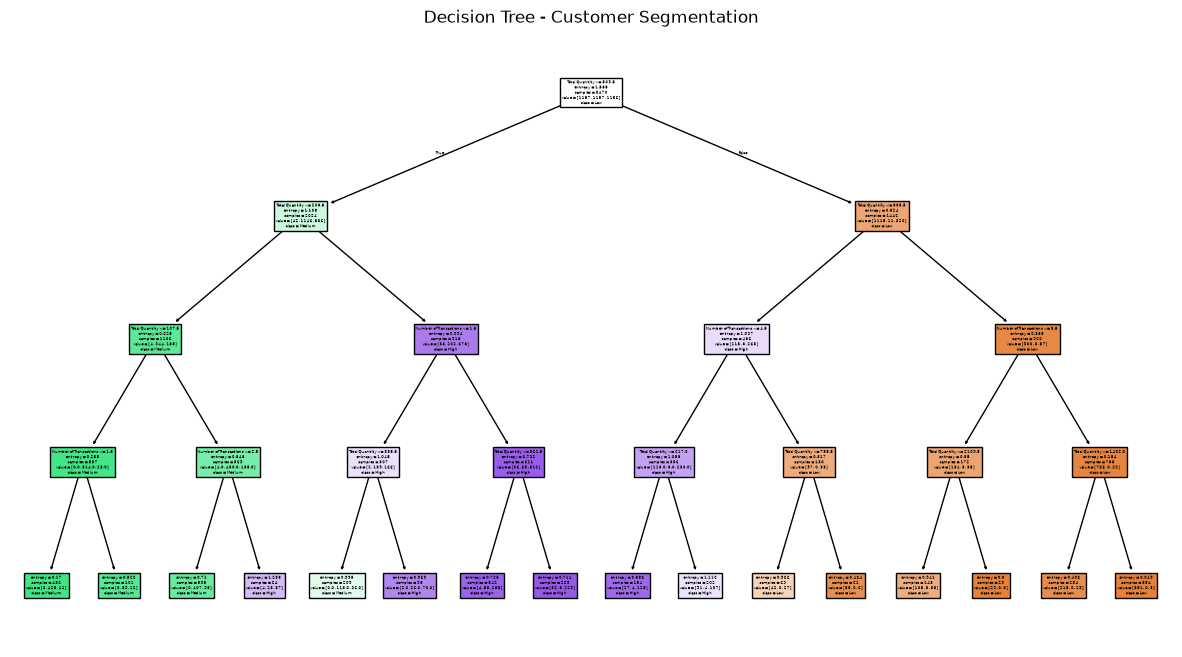

In [17]:
# Visualize Decision Tree
plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=["Total Quantity", "Number of Transactions"],
    class_names=["Low", "Medium", "High"],
    filled=True
)
plt.title("Decision Tree - Customer Segmentation")
plt.show()

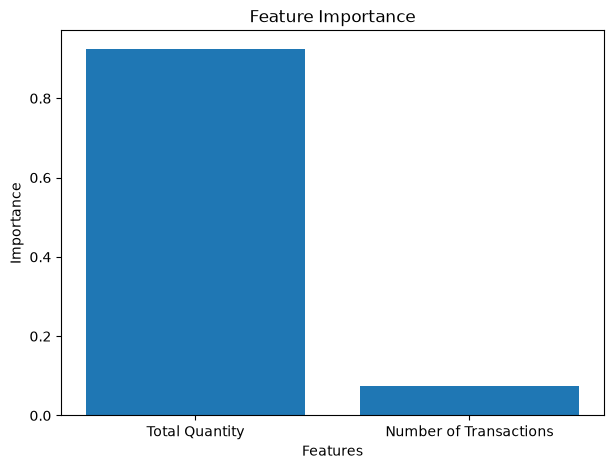

In [18]:
# Feature Importance Graph
features = ["Total Quantity", "Number of Transactions"]
importance = model.feature_importances_

plt.figure(figsize=(7, 5))
plt.bar(features, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()